### Ai Career Navigator Complete Eda Rebuild

# Exploratory Data Analysis (EDA)

# AI Career Navigator

# 1. Project Overview

   AI Career Navigator merupakan sistem berbasis Artificial Intelligence yang bertujuan membantu mahasiswa dan fresh graduate dalam memahami potensi karir, mengidentifikasi skill gap, serta memperoleh rekomendasi pembelajaran yang relevan dengan kebutuhan industri.

   Pada tahap Exploratory Data Analysis (EDA), dilakukan eksplorasi terhadap dataset career recommendation dan dataset Udemy course untuk memahami distribusi data, pola hubungan antar variabel, serta insight yang mendukung pengembangan sistem recommendation dan model AI.

# 2. Business Understanding
   Problem Statement

   Mahasiswa dan fresh graduate sering mengalami kesulitan dalam menentukan arah karir serta tidak mengetahui keterampilan apa yang dibutuhkan industri.

   Business Goal
   Mengembangkan sistem yang mampu:
   1. Mengklasifikasikan pekerjaan berdasarkan skill pengguna.
   2. Mengidentifikasi skill gap antara pengguna dan kebutuhan industri.
   3. Memberikan rekomendasi course pembelajaran yang relevan.

# 3. Dataset Mapping
- cleaned_career_recomendation.csv berfungsi sebagai Dataset utama untuk analisis pekerjaan, skill, dan   career recommendation.
- cleaned_udemy_course_details.csv berfungsi sebagai Dataset pendukung untuk learning recommendation

# 4. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

# 5. Load Dataset

In [2]:
career_df = pd.read_csv('cleaned_career_recomendation.csv')
udemy_df = pd.read_csv('cleaned_udemy_course_details.csv')

# 6. Preview Dataset

In [3]:
# Career Dataset
career_df.head()
career_df.info()

# Udemy Dataset
udemy_df.head()
udemy_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1195 entries, 0 to 1194
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1195 non-null   str    
 1   gender             1195 non-null   str    
 2   study_field        1195 non-null   str    
 3   ug_specialization  1195 non-null   str    
 4   interests          1195 non-null   str    
 5   skills             1195 non-null   str    
 6   ug_score           1195 non-null   float64
 7   has_certification  1195 non-null   str    
 8   title              1195 non-null   str    
 9   is_working         1195 non-null   str    
 10  first_job_title    1195 non-null   str    
 11  masters_field      1195 non-null   str    
dtypes: float64(1), str(11)
memory usage: 392.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 3672 entries, 0 to 3671
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 

# 7. Assessing Data
## Business Question
Apakah dataset memiliki kualitas data yang baik untuk mendukung proses analisis dan modeling?

In [4]:
# Missing Value
career_df.isnull().sum()
udemy_df.isnull().sum()

id             0
title          0
url            0
paid           0
price          0
subscribers    0
reviews        0
lectures       0
level          0
duration       0
study_field    0
dtype: int64

In [5]:
# Duplication Value
career_df.duplicated().sum()
udemy_df.duplicated().sum()

np.int64(0)

## Insight
Dataset career recommendation memiliki 1195 data dan tidak ditemukan missing value maupun duplicate sehingga dataset cukup siap digunakan pada tahap analisis.

Dataset Udemy course memiliki 3672 data dan juga tidak ditemukan missing value maupun duplicate sehingga dapat digunakan untuk mendukung fitur learning recommendation.

# 8. Cleaning Data
## Business Question
Bagaimana mempersiapkan data teks agar siap digunakan pada tahap analisis dan modeling?

In [6]:
# Lowercase
career_df['skills'] = career_df['skills'].str.lower()

In [7]:
# remove Spesial Character
def clean_text(text):
    text = re.sub(r'[^a-zA-Z,; ]', '', str(text))
    return text

career_df['skills'] = career_df['skills'].apply(clean_text)

## Insight
Proses cleaning dilakukan untuk mengurangi noise pada data teks sehingga proses analisis skill dan modeling NLP menjadi lebih optimal.

# 9. Exploratory Data Analysis (EDA)
# 9.1 Distribusi Bidang Studi
## business Question
Bidang studi apa yang paling dominan pada dataset career recommendation?

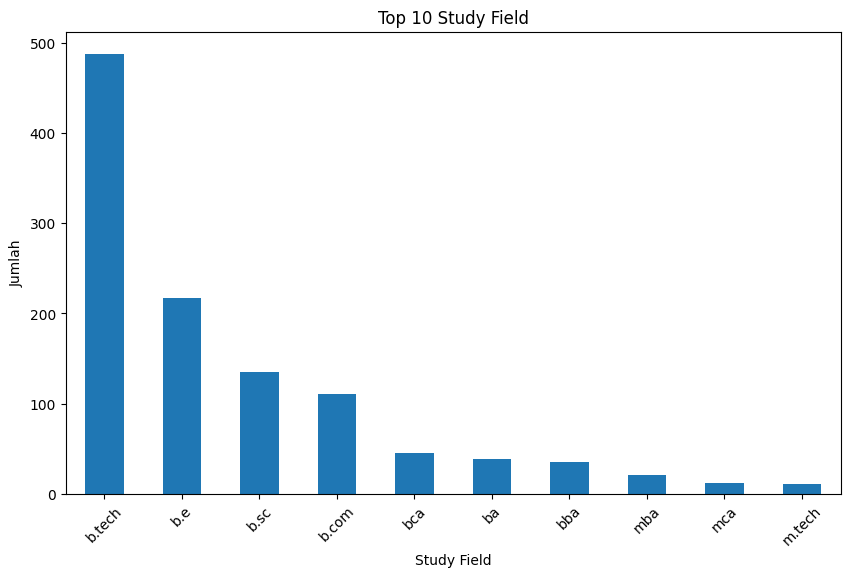

In [8]:
plt.figure(figsize=(10,6))
career_df['study_field'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Study Field')
plt.xlabel('Study Field')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.show()

## insight
Bidang studi seperti b.tech, b.sc, dan b.e mendominasi dataset. Hal ini menunjukkan bahwa mayoritas data berasal dari latar belakang pendidikan teknologi dan engineering.

# 9.2 Distribusi First Job Title
## Business Question
Pekerjaan pertama apa yang paling banyak muncul pada dataset?

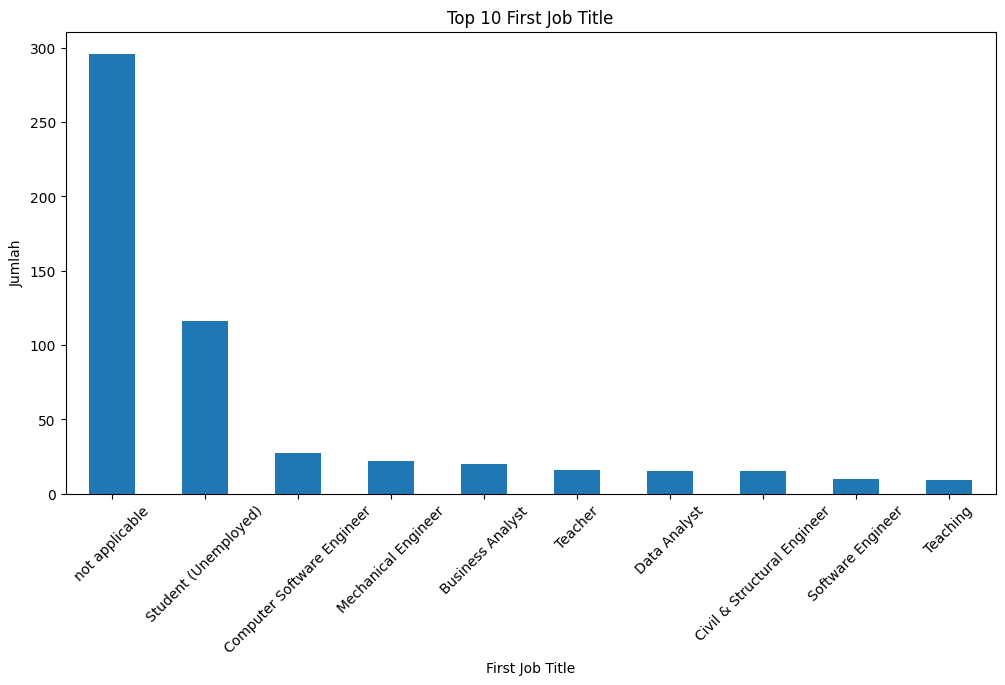

In [9]:
plt.figure(figsize=(12,6))
career_df['first_job_title'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 First Job Title')
plt.xlabel('First Job Title')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.show()

## Insight
Beberapa pekerjaan seperti Software Engineer, Computer Software Engineer, dan Data Analyst muncul lebih dominan dibanding pekerjaan lainnya.

Insight ini penting karena distribusi pekerjaan dapat mempengaruhi performa model klasifikasi.

# 9.3 Distribusi Status Kerja
## Business Question
Bagaimana distribusi status pekerjaan pada dataset?

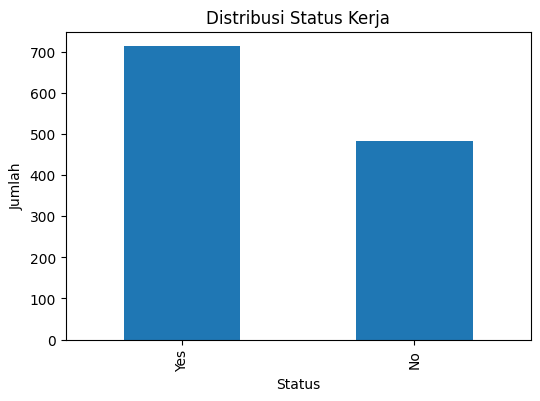

In [10]:
plt.figure(figsize=(6,4))
career_df['is_working'].value_counts().plot(kind='bar')

plt.title('Distribusi Status Kerja')
plt.xlabel('Status')
plt.ylabel('Jumlah')
plt.show()

## Insight
Sebagian besar data berasal dari pengguna yang sudah bekerja, namun masih terdapat pengguna dengan status belum bekerja atau student.

# 9.4 Top Skill Analysis
## Business Question
Skill apa yang paling dominan pada dataset?

In [11]:
all_skills = []

for skills in career_df['skills']:
    split_skills = str(skills).replace(';', ',').split(',')

    for skill in split_skills:
        skill = skill.strip().lower()

        if skill:
            all_skills.append(skill)

skill_counter = Counter(all_skills)

top_skills = skill_counter.most_common(15)

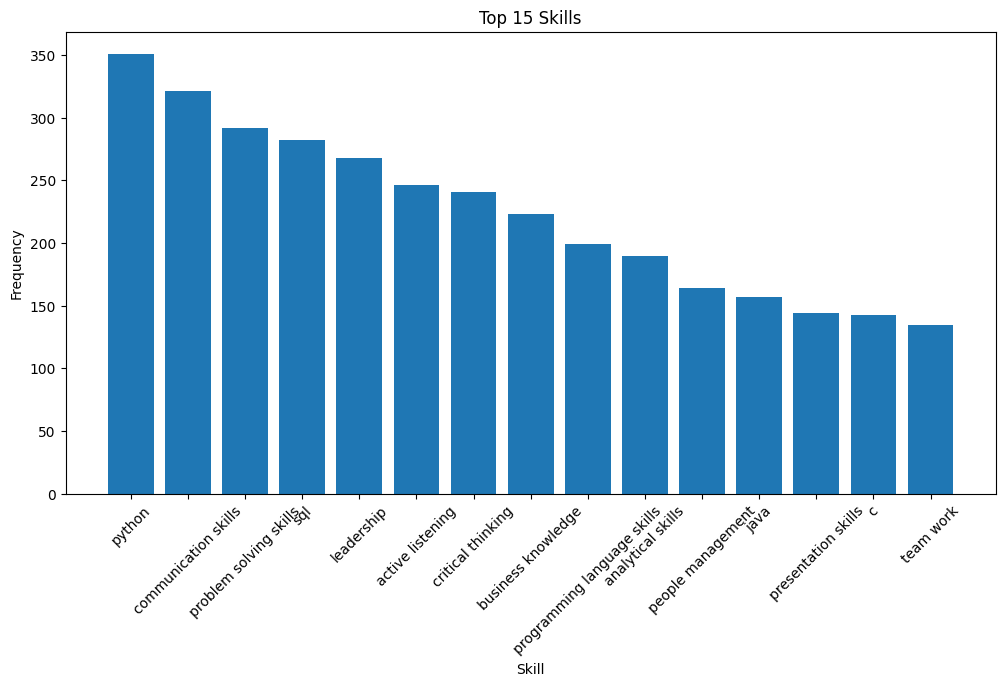

In [12]:
skills = [x[0] for x in top_skills]
counts = [x[1] for x in top_skills]

plt.figure(figsize=(12,6))
plt.bar(skills, counts)

plt.title('Top 15 Skills')
plt.xlabel('Skill')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

## Insight
Skill seperti Python, SQL, Java, dan Communication Skills menjadi skill yang paling dominan pada dataset.

Insight ini penting karena skill dominan dapat digunakan sebagai dasar fitur skill gap analysis dan recommendation system.

# 9.5 Top Skills per Job
## business Question
Skill apa yang paling dominan pada setiap katagori pekerjaan?

In [13]:
top_jobs = career_df['first_job_title'].value_counts().head(5).index

filtered_df = career_df[
    career_df['first_job_title'].isin(top_jobs)
]

In [14]:
job_skill_dict = {}

for job in top_jobs:

    skills = filtered_df[
        filtered_df['first_job_title'] == job
    ]['skills']

    all_skills = []

    for skill_text in skills:
        split_skills = str(skill_text).replace(';', ',').split(',')

        for skill in split_skills:
            skill = skill.strip().lower()

            if skill:
                all_skills.append(skill)

    common_skills = Counter(all_skills).most_common(5)

    job_skill_dict[job] = common_skills

In [15]:
job_skill_dict

{'not applicable': [('python', 138),
  ('programming language skills', 99),
  ('problem solving skills', 95),
  ('sql', 93),
  ('communication skills', 90)],
 'Student (Unemployed)': [('problem solving skills', 35),
  ('leadership', 35),
  ('python', 34),
  ('communication skills', 33),
  ('team work', 33)],
 'Computer Software Engineer': [('sql', 13),
  ('programming', 12),
  ('team work', 11),
  ('python', 10),
  ('java', 10)],
 'Mechanical Engineer': [('team work', 9),
  ('excel', 8),
  ('python', 7),
  ('leadership', 6),
  ('work under pressure', 6)],
 'Business Analyst': [('business knowledge', 8),
  ('leadership', 6),
  ('accounting skills', 5),
  ('communication skills', 5),
  ('sql', 4)]}

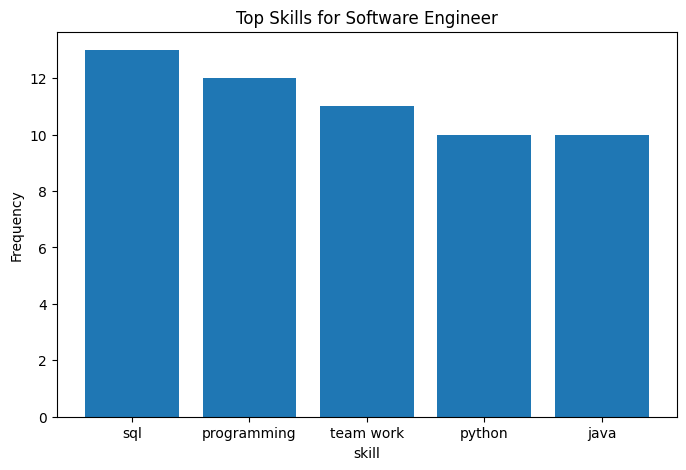

In [16]:
# Visualisasi Exemle untuk Software Engineer

skills = [x[0] for x in job_skill_dict['Computer Software Engineer']]
counts = [x[1] for x in job_skill_dict['Computer Software Engineer']]

plt.figure(figsize=(8,5))
plt.bar(skills, counts)

plt.title('Top Skills for Software Engineer')
plt.xlabel('skill')
plt.ylabel('Frequency')
plt.show()

## Insight
Pekerjaan Software Engineer didominasi oleh skill seperti Python, Java, dan SQL.

Insight ini sangat penting karena nantinya sistem recommendation akan bekerja berdasarkan hubungan antara skill dan pekerjaan.

# 9.6 Study Field vs First Job Title
## Business Question
Apakah terdapat hubungan antara bidang studi dan pekerjaan pertama?

In [17]:
top_jobs = career_df['first_job_title'].value_counts().head(10).index
top_fields = career_df['study_field'].value_counts().head(10).index

filtered_df = career_df[
    career_df['first_job_title'].isin(top_jobs) &
    career_df['study_field'].isin(top_fields)
]

In [18]:
cross_tab = pd.crosstab(
    filtered_df['study_field'],
    filtered_df['first_job_title']
)

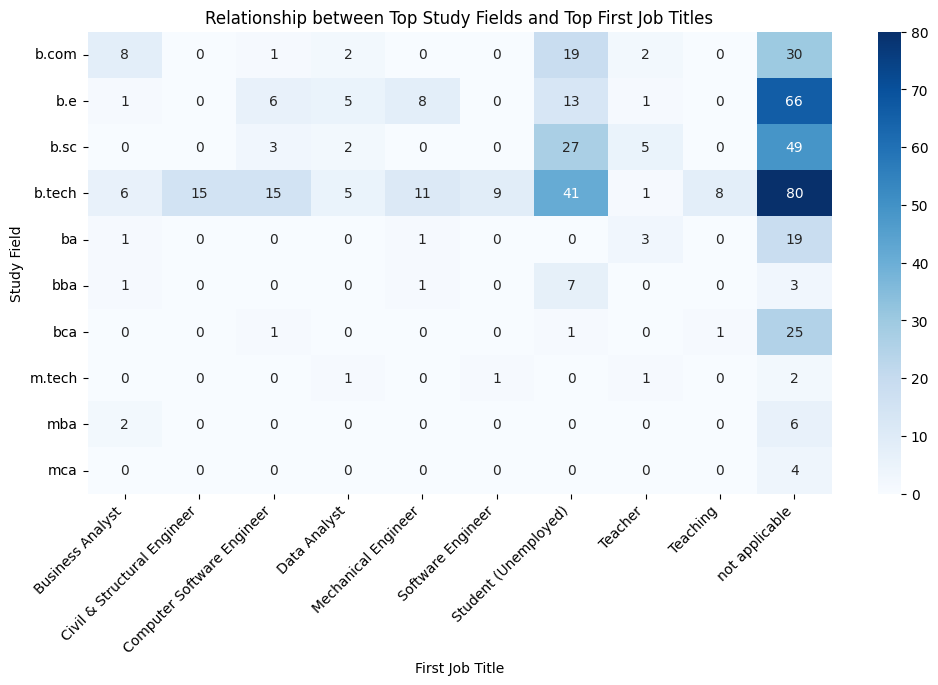

In [19]:
plt.figure(figsize=(12,6))

sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Relationship between Top Study Fields and Top First Job Titles')
plt.xlabel('First Job Title')
plt.ylabel('Study Field')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

## Insight
Beberapa bidang studi memiliki keterkaitan dengan pekerjaan tertentu, namun distribusinya masih cukup tersebar.

Hal ini menunjukkan bahwa recommendation system tidak cukup hanya mempertimbangkan bidang studi, tetapi juga perlu mempertimbangkan skill pengguna.

# 9.7 Skill Text Leghth Analysis
## Business Question
Bagaimana distribusi panjang teks skill pada dataset?


In [20]:
career_df['skill_length'] = career_df['skills'].str.len()

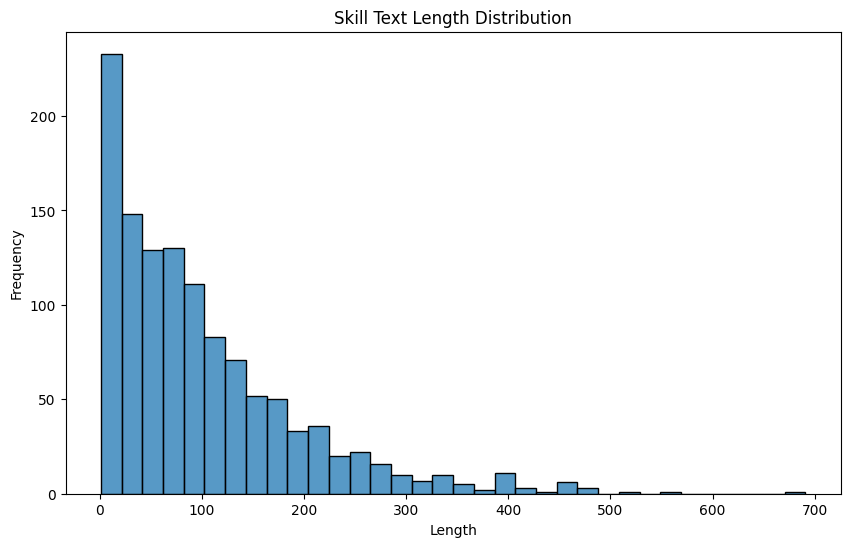

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(career_df['skill_length'])

plt.title('Skill Text Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

## Insight
Sebagian besar data memiliki panjang teks skill menengah, namun terdapat beberapa outlier dengan tes yang sangat panjang.

# 10. Udemy Course Analysis
# 10.1. Course Level Distribution
## Business Question
level course apa yang paling banyak tersedia?

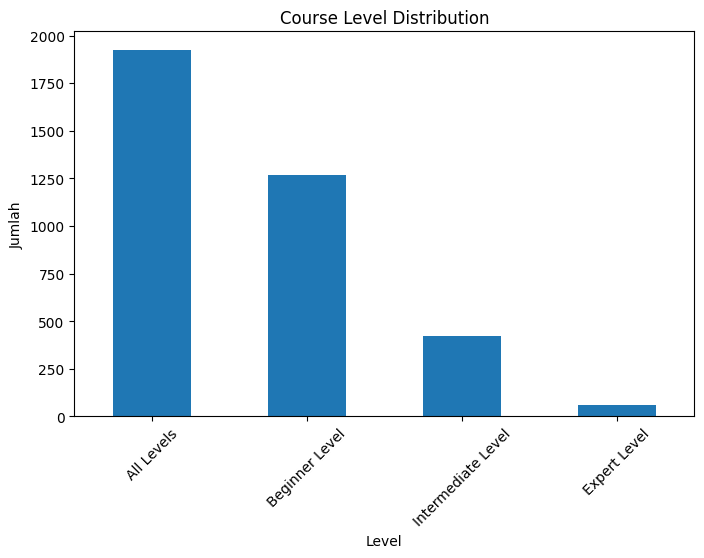

In [22]:
plt.figure(figsize=(8,5))
udemy_df['level'].value_counts().plot(kind='bar')

plt.title('Course Level Distribution')
plt.xlabel('Level')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.show()

## insight
Sebagian besar course berada pada level beginner dan intermediate.

Hal ini menunjukkan bahwa dataset course cukup relevan untuk pengguna mahasiswa dan fresh graduate.

# 10.2. Top Course Category
## Business Question
Kategori course apa yang paling populer berdasarkan jumlah subscriber?


In [23]:
top_courses = udemy_df.sort_values(
    by='subscribers',
    ascending=False
).head(10)

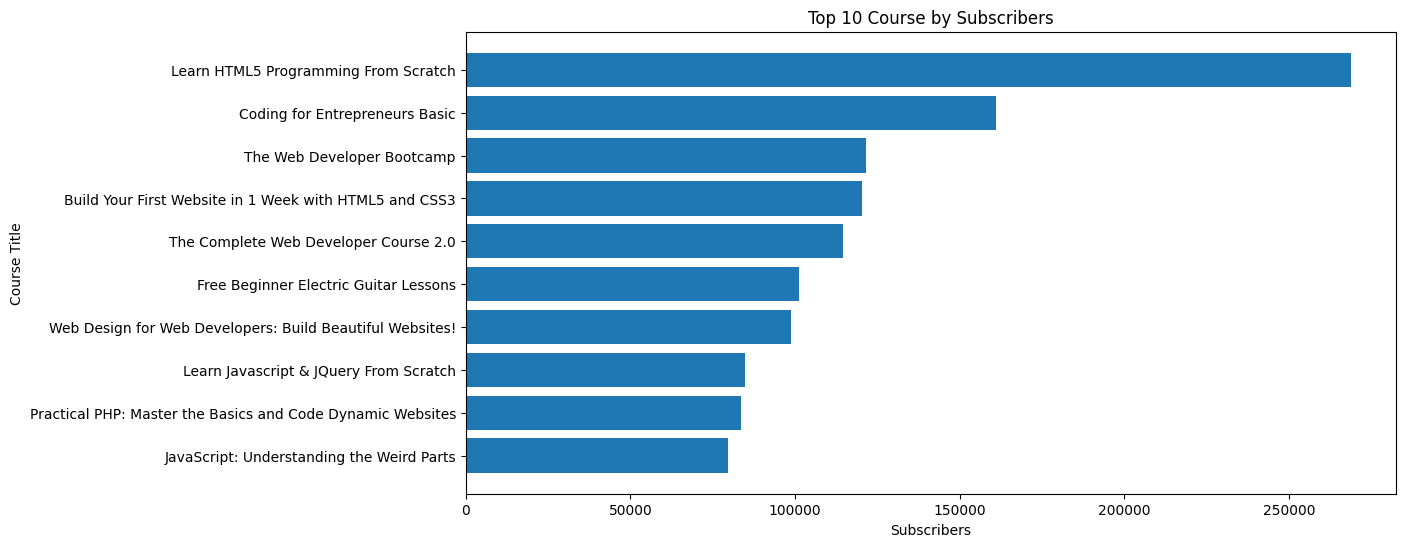

In [24]:
plt.figure(figsize=(12,6))

plt.barh(
    top_courses['title'],
    top_courses['subscribers']
)

plt.title('Top 10 Course by Subscribers')
plt.xlabel('Subscribers')
plt.ylabel('Course Title')
plt.gca().invert_yaxis()
plt.show()

## Insight
Course dengan jumlah subscriber tinggi dapat digunakan sebagai rekomendasi pembelajaran utama, karena menunjukan popularitas dan minat pengguna yang tinggi.

# 11. Data Dictionary

| Kolom | Deskripsi |
|---|---|
| `study_field` | Bidang studi pengguna |
| `skills` | Skill yang dimiliki pengguna |
| `first_job_title` | Pekerjaan pertama pengguna |
| `is_working` | Status pekerjaan |
| `level` | Tingkat course |
| `title` | Nama course |
| `subscribers` | Jumlah subscriber course |

# 12. Preparation for Modeling

Tahap selanjutnya akan dilakukan preprocessing NLP berupa:

1. Lowercase
2. Tokenization
3. Stopword Removal
4. TF-IDF Vectorization
5. Train Test Split

Output dari tahap ini akan digunakan untuk proses training model Deep Learning.

# 13. Conlusion
Berdasarkan hasil EDA, dataset career recommendation dapat digunakan sebagai dataset utama untuk mendukung fitur job classification dan skill gap analysis.

Analisis menunjukkan bahwa skill memiliki hubungan yang lebih kuat terhadap pekerjaan dibanding hanya bidang studi.

Dataset Udemy course juga dapat dimanfaatkan untuk mendukung fitur learning recommendation berdasarkan skill yang belum dimiliki pengguna.

Hasil EDA ini menjadi dasar penting sebelum masuk ke tahap preprocessing NLP, feature engineering, dan modeling AI.